In [1]:
!pip -q install xgboost

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


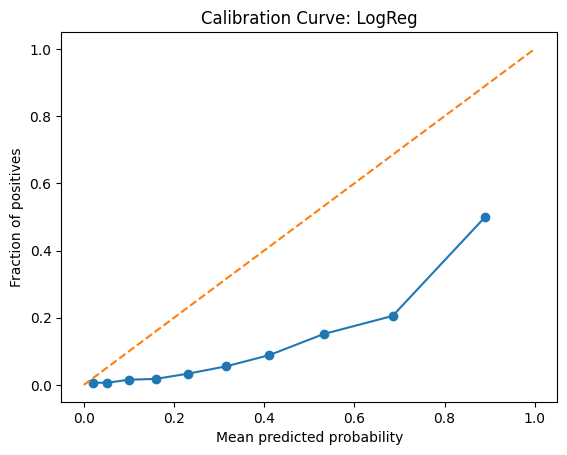

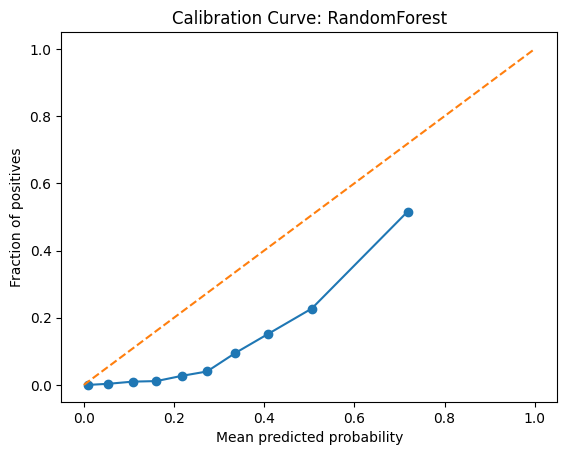

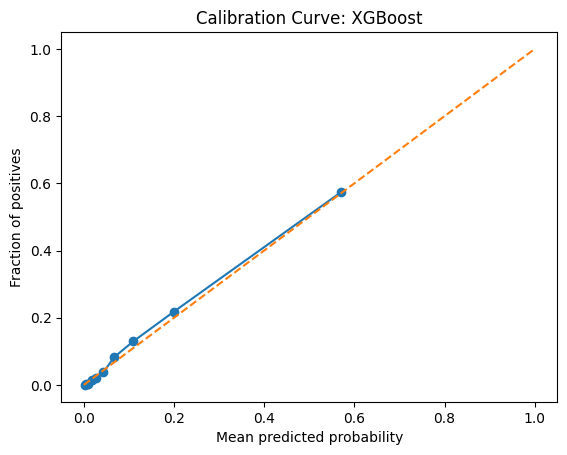

,Model,AUROC,AUPRC,Brier,Threshold(Recall≥0.80),Precision,Recall,Specificity,F1
2,XGBoost,0.898397,0.612594,0.063139,0.107741,0.346845,0.800151,0.817418,0.483922
1,RandomForest,0.881689,0.538742,0.106368,0.388114,0.314886,0.802413,0.788449,0.452285
0,LogReg,0.857553,0.503008,0.150162,0.460066,0.282933,0.800151,0.754272,0.418046


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# ---- Config ----
OUT_DIR = "/content/drive/MyDrive/mimic_outputs"
PATH = OUT_DIR + "/train_structured_vitals_labs_24h.parquet"

ID_COLS = ["icustay_id", "hadm_id", "subject_id", "intime", "outtime"]
Y_COL = "hospital_expired"
GROUP_COL = "subject_id"

# Thresholding policy: choose the threshold that maximizes precision subject to recall >= TARGET_RECALL
TARGET_RECALL = 0.80

# ---- Load dataset ----
df = pd.read_parquet(PATH)

# ---- Patient-level split (prevents leakage across multiple stays per patient) ----
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_tr, idx_te = next(gss.split(df, df[Y_COL], groups=df[GROUP_COL]))
tr = df.iloc[idx_tr].copy()
te = df.iloc[idx_te].copy()

y_tr = tr[Y_COL].astype(int).values
y_te = te[Y_COL].astype(int).values

drop_cols = ID_COLS + [Y_COL]
X_tr = tr.drop(columns=drop_cols, errors="ignore")
X_te = te.drop(columns=drop_cols, errors="ignore")

# ---- Preprocessing (numeric impute + scaling; categorical impute + one-hot) ----
num_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_tr.columns if c not in num_cols]

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False)),  # helpful for LogReg; harmless for trees
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

# ---- Models ----
models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=20,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42
    ),
}

def pick_threshold_at_recall(y_true, y_prob, target_recall=0.8):
    """
    Select the threshold that maximizes precision subject to recall >= target_recall.
    """
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    # precision_recall_curve returns thr with length = len(prec) - 1
    prec2, rec2 = prec[:-1], rec[:-1]
    ok = rec2 >= target_recall
    if not np.any(ok):
        # If target recall is unattainable, pick the point with the highest recall
        best = np.argmax(rec2)
    else:
        # Among points meeting recall, pick the one with max precision
        best = np.argmax(prec2[ok])
        best = np.where(ok)[0][best]
    return float(thr[best]), float(prec2[best]), float(rec2[best])

def cm_metrics(y_true, y_prob, thr):
    """
    Compute threshold-dependent metrics from the confusion matrix.
    """
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, specificity, f1

rows = []
probs = {}  # model_name -> predicted probabilities on the test set (for plotting/analysis)
pipes = {}  # model_name -> trained Pipeline (for reuse, e.g., SHAP)

for name, model in models.items():
    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(X_tr, y_tr)

    # Predicted probability of the positive class
    p = pipe.predict_proba(X_te)[:, 1]

    # Store for downstream plots / SHAP (no need to retrain later)
    probs[name] = p
    pipes[name] = pipe

    # Core metrics
    auroc = roc_auc_score(y_te, p)
    auprc = average_precision_score(y_te, p)
    brier = brier_score_loss(y_te, p)

    # Thresholded metrics at Recall >= TARGET_RECALL
    thr, prec_at, rec_at = pick_threshold_at_recall(y_te, p, TARGET_RECALL)
    precision, recall, specificity, f1 = cm_metrics(y_te, p, thr)

    rows.append({
        "Model": name,
        "AUROC": auroc,
        "AUPRC": auprc,
        "Brier": brier,
        f"Threshold(Recall≥{TARGET_RECALL:.2f})": thr,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,
    })

    # Calibration curve (reliability diagram)
    frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    plt.figure()
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(f"Calibration Curve: {name}")
    plt.show()

results = pd.DataFrame(rows).sort_values("AUPRC", ascending=False)
results

Across baseline models under patient-level group split, XGBoost performed best with AUROC ≈ 0.898 and AUPRC ≈ 0.613, and it also showed the best calibration (lowest Brier ≈ 0.063 with a curve closest to the diagonal). At the operating point constrained to Recall ≥ 0.80, XGBoost achieved Precision ≈ 0.347 (Specificity ≈ 0.817), outperforming Random Forest and Logistic Regression on both discrimination and probability reliability.

## SHAP FOR XGBoost

In [3]:
!pip -q install shap

X_test transformed shape: (12269, 274)
Feature count: 274


/tmp/ipython-input-403/3810401826.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_dense, feature_names=feature_names, plot_type="bar", max_display=20)


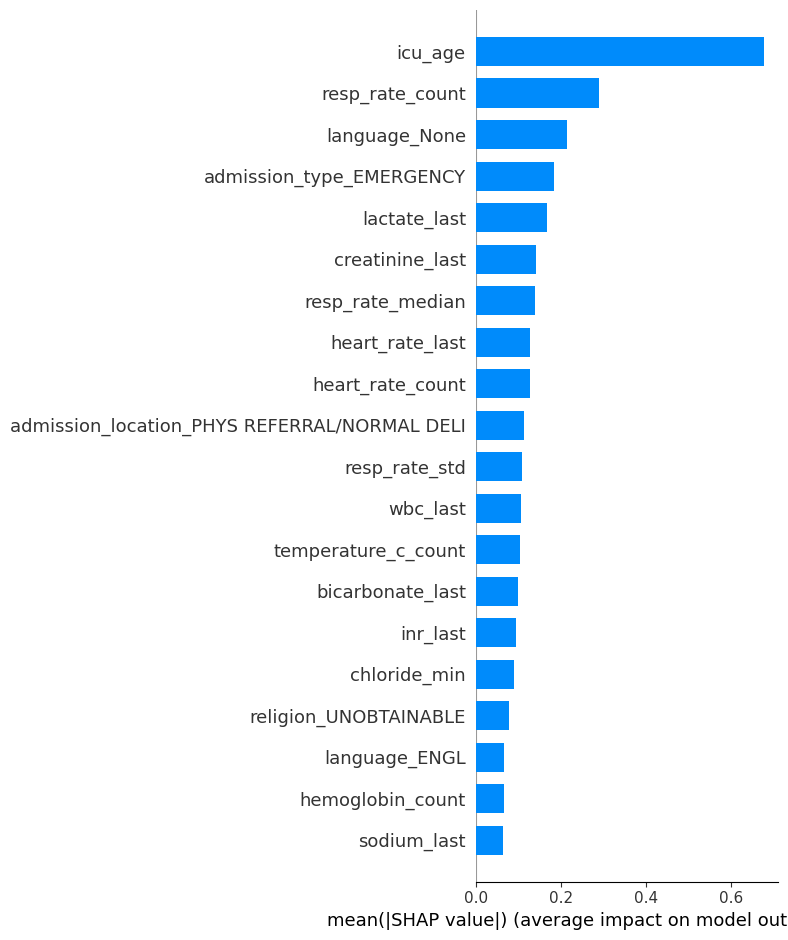

/tmp/ipython-input-403/3810401826.py:36: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_dense, feature_names=feature_names, max_display=20)


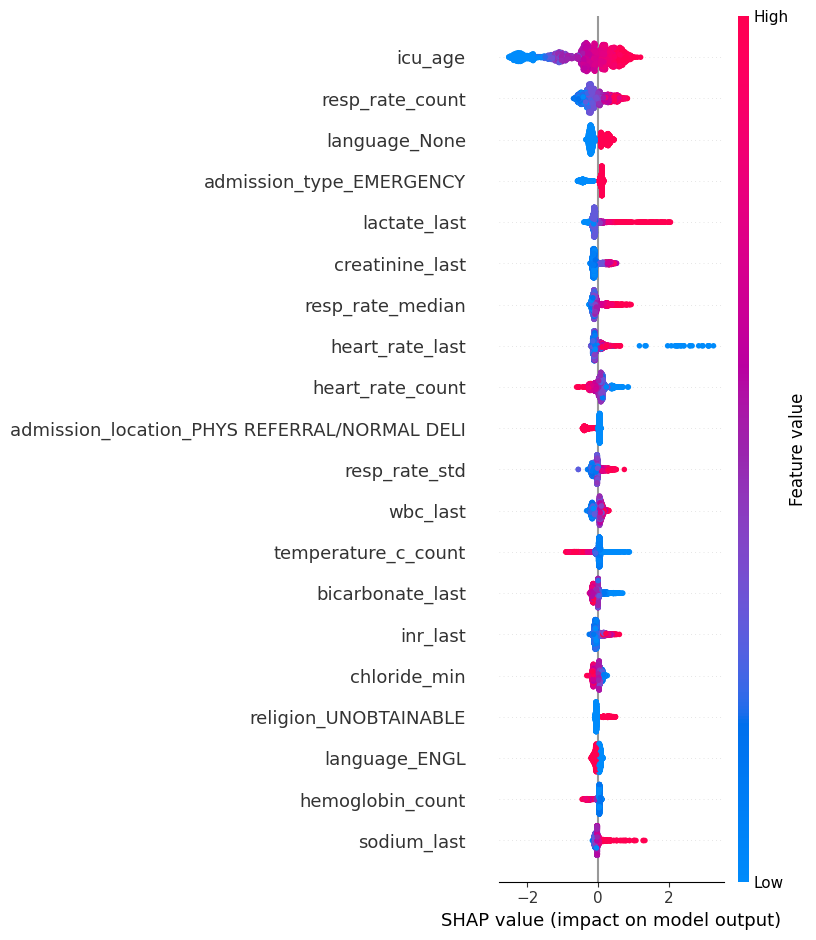

Highest predicted risk (test): 0.9999603033065796


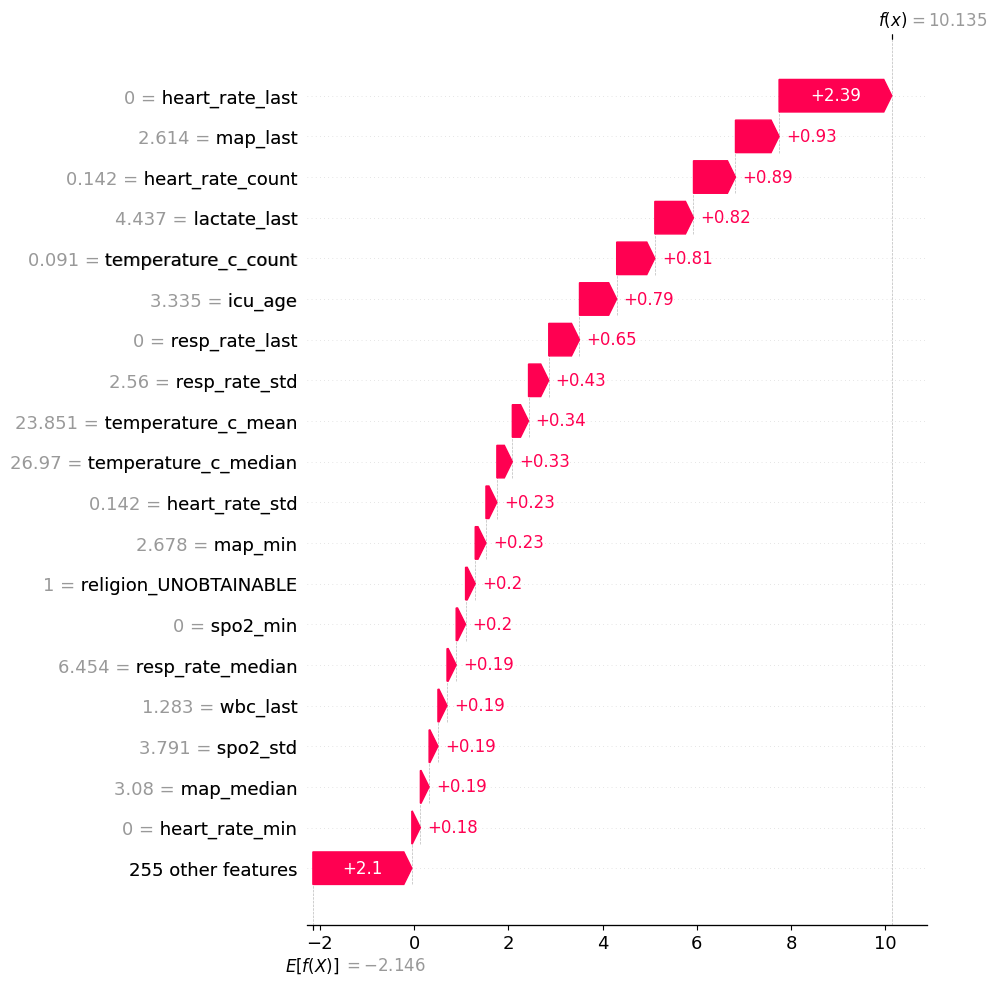

In [4]:
import shap
import scipy.sparse as sp

# 1) Reuse the trained XGBoost pipeline and test predictions
pipe_xgb = pipes["XGBoost"]
pre = pipe_xgb.named_steps["pre"]
model = pipe_xgb.named_steps["model"]

# 2) Transform the test set into the model input space (after impute/one-hot)
X_te_trans = pre.transform(X_te)

# 3) Recover feature names (numeric + one-hot categorical)
ohe = pre.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + cat_feature_names

print("X_test transformed shape:", X_te_trans.shape)
print("Feature count:", len(feature_names))

# 4) Subsample for speed (SHAP can be expensive on large test sets)
np.random.seed(42)
n = X_te_trans.shape[0]
idx = np.random.choice(n, size=min(3000, n), replace=False)

X_shap = X_te_trans[idx]

# Convert sparse -> dense for SHAP plotting stability
X_shap_dense = X_shap.toarray() if sp.issparse(X_shap) else X_shap

# 5) Compute SHAP values using TreeExplainer (fast for tree models)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap_dense)

# 6) Global importance (bar) and directionality (beeswarm)
shap.summary_plot(shap_values, X_shap_dense, feature_names=feature_names, plot_type="bar", max_display=20)
shap.summary_plot(shap_values, X_shap_dense, feature_names=feature_names, max_display=20)

# 7) Case-level explanation: pick the highest-risk test example and explain it
p_test = probs["XGBoost"]
top_i = int(np.argmax(p_test))

x1 = pre.transform(X_te.iloc[[top_i]])
x1_dense = x1.toarray() if sp.issparse(x1) else x1
sv1 = explainer.shap_values(x1_dense)

print("Highest predicted risk (test):", float(p_test[top_i]))

shap.waterfall_plot(
    shap.Explanation(
        values=sv1[0],
        base_values=explainer.expected_value,
        data=x1_dense[0],
        feature_names=feature_names
    ),
    max_display=20
)

SHAP analysis shows that the XGBoost model’s predictions are driven primarily by baseline risk and early physiologic/lab severity: icu_age is the strongest global contributor, followed by respiratory instability signals (resp_rate_count/median/std), cardiovascular stress (heart_rate_last/count), and key labs such as lactate_last and creatinine_last. Several administrative/missingness-related fields (e.g., language_None, religion_UNOBTAINABLE) also appear among the top features, suggesting documentation/process proxies that should be acknowledged and optionally tested via sensitivity analysis. by 24-hour vitals and labs.

In [5]:
# sensitivity analysis

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

PATH = "/content/drive/MyDrive/mimic_outputs/train_structured_vitals_labs_24h.parquet"
df = pd.read_parquet(PATH)

ID_COLS = ["icustay_id", "hadm_id", "subject_id", "intime", "outtime"]
Y_COL = "hospital_expired"
GROUP_COL = "subject_id"

# Fixed patient-level split (same split for both settings)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_tr, idx_te = next(gss.split(df, df[Y_COL], groups=df[GROUP_COL]))
tr, te = df.iloc[idx_tr].copy(), df.iloc[idx_te].copy()

y_tr = tr[Y_COL].astype(int).values
y_te = te[Y_COL].astype(int).values

def train_eval_xgb(X_tr, X_te, y_tr, y_te):
    num_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_tr.columns if c not in num_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop",
        sparse_threshold=0.3
    )

    model = XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
    )

    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(X_tr, y_tr)
    p = pipe.predict_proba(X_te)[:, 1]

    metrics = {
        "AUROC": roc_auc_score(y_te, p),
        "AUPRC": average_precision_score(y_te, p),
        "Brier": brier_score_loss(y_te, p),
    }
    return metrics, pipe, p  # return pipe and probs for reuse

# Build feature matrices
drop_base = ID_COLS + [Y_COL]
X_tr_full = tr.drop(columns=drop_base, errors="ignore")
X_te_full = te.drop(columns=drop_base, errors="ignore")

# Remove *_count features
count_cols = [c for c in X_tr_full.columns if c.endswith("_count")]
X_tr_nocount = X_tr_full.drop(columns=count_cols, errors="ignore")
X_te_nocount = X_te_full.drop(columns=count_cols, errors="ignore")

print("Removed *_count columns:", len(count_cols))
print(count_cols[:20])

# Run both settings
res_full, pipe_full, p_full = train_eval_xgb(X_tr_full, X_te_full, y_tr, y_te)
res_nocount, pipe_nocount, p_nocount = train_eval_xgb(X_tr_nocount, X_te_nocount, y_tr, y_te)

out = pd.DataFrame([
    {"Setting": "Full features (with *_count)", **res_full},
    {"Setting": "Remove *_count features", **res_nocount},
])
out["ΔAUROC (nocount - full)"] = out.loc[1, "AUROC"] - out.loc[0, "AUROC"]
out["ΔAUPRC (nocount - full)"] = out.loc[1, "AUPRC"] - out.loc[0, "AUPRC"]
out["ΔBrier (nocount - full)"] = out.loc[1, "Brier"] - out.loc[0, "Brier"]

out

Removed *_count columns: 16
['heart_rate_count', 'map_count', 'resp_rate_count', 'spo2_count', 'temperature_c_count', 'bicarbonate_count', 'bilirubin_total_count', 'chloride_count', 'creatinine_count', 'hemoglobin_count', 'inr_count', 'lactate_count', 'platelets_count', 'potassium_count', 'sodium_count', 'wbc_count']


,Setting,AUROC,AUPRC,Brier,ΔAUROC (nocount - full),ΔAUPRC (nocount - full),ΔBrier (nocount - full)
0,Full features (with *_count),0.897886,0.610408,0.063355,-0.007681,-0.014717,0.001353
1,Remove *_count features,0.890205,0.595692,0.064707,-0.007681,-0.014717,0.001353


Removing measurement-frequency proxies (*_count) leads to a modest but consistent drop in discrimination (AUROC/AUPRC) and slightly worse calibration (higher Brier), suggesting that monitoring intensity contains informative acuity signal; for transparency, results are reported with and without *_count features.
